# Creating an agent using LangGraph
This is based on the Ai Agents in Langgraph course on DeepLearning.ai, but it uses a custom tool and Ollama served LLMs. Ran on a Macbook M3 Max with 32GB memory. 

In [124]:
pip install langgraph langchain langchain-ollama langchain-core 

Note: you may need to restart the kernel to use updated packages.


In [126]:
import httpx 
import ollama 

from langgraph.graph import StateGraph, END 
# used to construct agent state
from typing import TypedDict, Annotated 
import operator 

# langchain message type
from langchain_core.messages import AnyMessage, ToolMessage, SystemMessage, HumanMessage 

# langchain wrapper for Ollama
from langchain_ollama import ChatOllama

# tool library
from langchain_core.tools import tool

llm = "qwen2.5:14b"

# load env variables for any api keys (Tavily, OpenAI, etc)
# originally I was using a Tavily community tool, but I built my own later so this isn't necessary 
# import os
# from dotenv import load_dotenv, find_dotenv
# load_dotenv(find_dotenv())

In [128]:
# tool for agent, sends an API request that gets the weather for a particular city
@tool
def get_weather(city: str) -> str:
    """Get current weather conditions for a single city."""
    import requests
    resp = requests.get(f"https://wttr.in/{city}?format=3")
    return resp.text

In [129]:
# create AgentState class 
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [130]:
class Agent: 
    def __init__(self, model, tools, system=""):
        self.system = system 
        graph = StateGraph(AgentState)
        # add a node for the LLM 
        graph.add_node("llm", self.call_ollama)
        graph.add_node("action", self.take_action)

        graph.add_conditional_edges(
            "llm", 
            self.exists_action,
            {True: "action", False:END }
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name:t for t in tools}

        # provides model w tool calls 
        self.model = model.bind_tools(tools)
        
    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0 
        
    def call_ollama(self, state: AgentState): 
         messages = state['messages']
         
         if self.system:
             messages = [SystemMessage(content=self.system)] + messages
         
         message = self.model.invoke(messages)
         return {'messages': [message]}
         
    def take_action(self, state: AgentState): 
         # get last message from list of messages 
         tool_calls = state['messages'][-1].tool_calls
         results = []
         
         for t in tool_calls: 
             print(f"calling {t}")
             result = self.tools[t['name']].invoke(t['args'])
             results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
         print("Back to model")
         return {'messages': results} 

In [131]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

model = ChatOllama(model=llm)  
abot = Agent(model, [get_weather], system=prompt)

In [132]:
pip install pygraphviz

Note: you may need to restart the kernel to use updated packages.


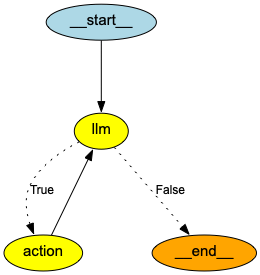

In [133]:
from IPython.display import Image

Image(abot.graph.get_graph().draw_png())

In [135]:
messages = [HumanMessage(content="What is the weather in sf?")]
result = abot.graph.invoke({"messages": messages})

calling {'name': 'get_weather', 'args': {'city': 'sf'}, 'id': '5d1add96-c6ae-4961-a0a8-3b488c956a5c', 'type': 'tool_call'}
Back to model
calling {'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': '1aeea4e8-3c47-4e78-a4fb-271512060dab', 'type': 'tool_call'}
Back to model


In [136]:
result

{'messages': [HumanMessage(content='What is the weather in sf?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen2.5:14b', 'created_at': '2026-09-23T07:00:19.409886Z', 'done': True, 'done_reason': 'stop', 'total_duration': 763791583, 'load_duration': 2778333, 'prompt_eval_count': 203, 'prompt_eval_duration': 63023000, 'eval_count': 20, 'eval_duration': 694003000, 'logprobs': None, 'model_name': 'qwen2.5:14b', 'model_provider': 'ollama'}, id='lc_run--01a0cd10-b253-7333-8a8b-34dbfa1d73e0-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'sf'}, 'id': '5d1add96-c6ae-4961-a0a8-3b488c956a5c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 203, 'output_tokens': 20, 'total_tokens': 223}),
  ToolMessage(content='Berlin: ☀️  +51°F\n', name='get_weather', tool_call_id='5d1add96-c6ae-4961-a0a8-3b488c956a5c'),
  AIMessage(content="It seems like there was an unexpected response for Berli

In [137]:
result['messages'][-1].content

'The current weather in San Francisco is partly cloudy with a temperature of 59°F.'

In [144]:
messages = [HumanMessage(content="What is the weather in SF and LA?")]
result = abot.graph.invoke({"messages": messages})
result

calling {'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': 'd7d71562-fa8f-43cc-aebd-d9856570573d', 'type': 'tool_call'}
calling {'name': 'get_weather', 'args': {'city': 'Los Angeles'}, 'id': '13d06c05-11b3-4131-a1c1-2a31a1ee561b', 'type': 'tool_call'}
Back to model


{'messages': [HumanMessage(content='What is the weather in SF and LA?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen2.5:14b', 'created_at': '2026-09-23T07:02:19.018344Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1522637750, 'load_duration': 3131041, 'prompt_eval_count': 205, 'prompt_eval_duration': 59010000, 'eval_count': 42, 'eval_duration': 1455480000, 'logprobs': None, 'model_name': 'qwen2.5:14b', 'model_provider': 'ollama'}, id='lc_run--01a0cd12-8294-7902-b164-3feb0af7e2fa-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': 'd7d71562-fa8f-43cc-aebd-d9856570573d', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'city': 'Los Angeles'}, 'id': '13d06c05-11b3-4131-a1c1-2a31a1ee561b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 205, 'output_tokens': 42, 'total_tokens': 247}),
  ToolMessage(content='San Francisco: 🌤️  +59°F\n',

In [142]:
result['messages'][-1].content

'The current weather in San Francisco is sunny with a temperature of 59°F. In Los Angeles, it is also sunny, but a bit warmer at 71°F.'